# 라우팅 심화, `Command` 로 동적 분기
- `add_conditional_edges` 는 "그래프 짤 때 미리 정한 분기" 였습니다. LangGraph 1.0+ 의 **`Command`** 는 **노드 안에서 직접 다음 노드를 지정** 할 수 있어 훨씬 유연. ReAct 같은 동적 흐름에 핵심.

## 환경 준비

```
OPENAI_API_KEY=sk-...
LANGSMITH_API_KEY=lsv2_pt_...
LANGSMITH_TRACING=true
LANGSMITH_PROJECT=mtvs2026-langgraph
```

In [2]:
from dotenv import load_dotenv
import os

load_dotenv()
print("OPENAI_API_KEY:", "있음" if os.getenv("OPENAI_API_KEY") else "없음")

OPENAI_API_KEY: 있음


## 1. `Command` 가 뭐가 다른가

기존 방식 :
```
노드 → 다음 노드 결정 (add_conditional_edges)
노드의 반환 = state 만
```

새 방식 (LangGraph 1.0+):
```
노드 → Command(goto="다음 노드", update={...state 변경...})
       노드의 반환 안에 "다음 어디로" 가 직접 들어있음
```

장점: 노드 함수 한 곳에서 "상태 변경 + 다음 분기" 를 같이. 코드 흐름이 직관적.

>LangGraph 공식 문서 기준으로 add_conditional_edges는 노드가 끝난 뒤 라우팅 함수를 호출해서 다음 노드를 결정하는 방식이고, Command는 노드 함수가 상태 업데이트와 다음 이동 위치를 한 번에 반환하는 방식입니다.

## 2. 가장 단순한 Command 예시

### `Command[Literal["pass_node", "fail_node"]]` 가 의미하는 것

- 타입 힌트로 "이 노드는 'pass_node' 또는 'fail_node' 중 하나로 갈 수 있다" 는 걸 명시. IDE 자동완성·LangGraph 시각화·실행 시 검증에 사용. `__end__` 를 적으면 그래프 종료.

```python
Command[Literal["a", "b", "__end__"]]    # a, b, END 중 하나
```

In [3]:
from typing import Annotated
from typing_extensions import Literal
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.graph.message import add_messages
from langgraph.types import Command
from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage, AIMessage

In [4]:
llm = init_chat_model("openai:gpt-5.4-mini")

def grade_answer(state: MessagesState) -> Command[Literal["pass_node", "fail_node"]]:
    """마지막 메시지에 주문번호나 처리 가능 키워드가 있으면 pass, 아니면 fail 로 이동."""
    last = state["messages"][-1].content.lower()
    is_pass = "o-" in last or "가능" in last or "확인" in last
    return Command(
        # 다음 노드를 함수 안에서 직접 지정
        goto='pass_node' if is_pass else "fail_node",
        # 동시에 state도 업데이터(선택)
        update={'messages': [AIMessage(f"[검토 결과]{'처리 가능' if is_pass else '추가 정보 필요'}")]}
    )

def pass_node(state: MessagesState) -> dict:
    return {"messages": [AIMessage("주문 정보가 확인되었습니다. 다음 처리 단계로 이동합니다.")]}


def fail_node(state: MessagesState) -> dict:
    return {"messages": [AIMessage("주문번호나 문의 유형을 먼저 확인해야 합니다.")]}

In [5]:
graph = StateGraph(MessagesState)
graph.add_node("grade", grade_answer)
graph.add_node("pass_node", pass_node)
graph.add_node("fail_node", fail_node)
graph.add_edge(START, "grade")
graph.add_edge("pass_node", END)
graph.add_edge("fail_node", END)

app = graph.compile()

In [6]:
# 처리 가능 시나리오
result1 = app.invoke({"messages": [HumanMessage("주문번호 O-1001 확인 가능합니다.")]})
for m in result1["messages"]:
    print(f"  [{type(m).__name__}] {m.content}")

print()

# 추가 정보 필요 시나리오
result2 = app.invoke({"messages": [HumanMessage("배송이 안 왔어요.")]})
for m in result2["messages"]:
    print(f"  [{type(m).__name__}] {m.content}")

  [HumanMessage] 주문번호 O-1001 확인 가능합니다.
  [AIMessage] [검토 결과]처리 가능
  [AIMessage] 주문 정보가 확인되었습니다. 다음 처리 단계로 이동합니다.

  [HumanMessage] 배송이 안 왔어요.
  [AIMessage] [검토 결과]추가 정보 필요
  [AIMessage] 주문번호나 문의 유형을 먼저 확인해야 합니다.


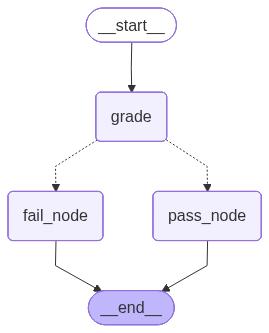

In [7]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

## 3. Command 와 conditional_edges 비교

| 항목 | `add_conditional_edges` | `Command(goto=...)` |
|---|---|---|
| 다음 노드 결정 위치 | 별도 라우터 함수 | 노드 함수 내부 |
| 상태 업데이트 + 분기 | 두 단계로 분리 | 한 줄에 통합 (`update=...`) |
| 코드 양 | 노드 + 라우터 + add_conditional_edges | 노드 하나 |
| 가독성 | 분기가 명시적 | 흐름이 자연스러움 |
| 추천 | 분기 규칙이 고정 | 동적·여러 조건 결합 |

## 4. 여러 단계 동적 분기, 티켓 처리 진행도

`Command` 로 "티켓 처리 상태에 따라" 다른 노드로 보내는 시나리오. State 에 진행 단계를 두고 매 노드에서 +1.


In [8]:
from typing import TypedDict


class TicketFlowState(TypedDict):
    messages: Annotated[list, add_messages]
    stage: int                      # 0 -> 1 -> 2 -> 3으로 진행

In [15]:
def stage_start(state: TicketFlowState) -> Command[Literal['stage_policy_check', 'stage_order_check']]:
    """처리 시작 후, 짝수 stage 면 주문 확인으로, 홀수면 정책 확인으로."""
    next_stage = state["stage"] + 1
    goto = "stage_order_check" if next_stage % 2 == 0 else "stage_policy_check"
    return Command(
        goto=goto,
        update={"stage": next_stage, "messages":[HumanMessage(f"[stage {next_stage}] 처리 시작")]}
    )

def stage_order_check(state: TicketFlowState) -> Command[Literal['stage_start', "__end__"]]:
    """주문/배송 상태 확인. stage 3 이상이면 답변 발송 후 종료."""
    if state["stage"] >= 3:
        return Command(
            #goto=END,
            goto="__end__",
            update={"messages": [HumanMessage("고객 답변 발송 완료. 티켓 종료.")]})
    return Command(
        goto="stage_start",
        update={"messages":[HumanMessage(f"[stage {state['stage']}]  주문/배송 상태 확인 완료")]}
    )

def stage_policy_check(state: TicketFlowState) -> Command[Literal['stage_start']]:
    """환불/보상 정책 확인 후 다음 단계로."""
    return Command(
        goto='stage_start',
        update={"messages":[HumanMessage(f"[stage {state['stage']}]  환불/보상 정책 확인 완료")]}
    )

In [21]:
graph_ticket = StateGraph(TicketFlowState)
graph_ticket.add_node("stage_start", stage_start)
graph_ticket.add_node("stage_order_check", stage_order_check)
graph_ticket.add_node("stage_policy_check", stage_policy_check)
graph_ticket.add_edge(START, "stage_start")

app_ticket = graph_ticket.compile()

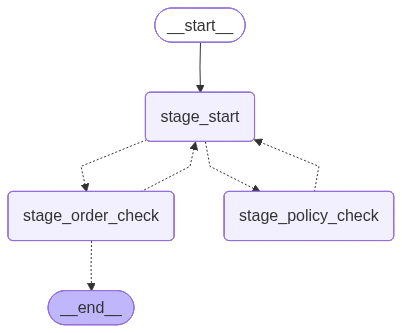

In [19]:
from IPython.display import Image, display

display(Image(app_ticket.get_graph().draw_mermaid_png()))


## 5. 정리

- `Command(goto=..., update={...})` 한 줄로 **다음 노드 + 상태 변경** 동시에
- 노드 시그니처에 `-> Command[Literal["a", "b"]]` 적어두면 어디로 갈 수 있는지 명시 (타입체커·시각화에 도움)
- `recursion_limit` 으로 무한 루프 방지
- 다음 노트북에서 ReAct 패턴에 `Command` 가 어떻게 자연스럽게 들어가는지 봅니다

## [실습]

1. 고객지원 키워드 라우팅 만들기: `grade_answer`의 판정 기준을 주문/배송/환불/반품 업무 키워드로 바꾸고 pass/fail 흐름을 확인하세요.
2. 티켓 처리 그래프 확장하기: `stage_manager_review` 노드를 추가하고, `actions: Annotated[list[str], operator.add]`로 각 stage의 처리 이력을 누적하세요.
3. 반복 안전장치 확인하기: `recursion_limit=5`로 한계 초과 에러를 확인한 뒤, 충분한 값으로 올려 정상 종료 흐름을 비교하세요.
